<a href="https://colab.research.google.com/github/SahilPurabiya/PythonForAstronomy/blob/main/SDSS_Spectra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Install if needed (run once)
!pip install astroquery astropy matplotlib --quiet
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import numpy as np
from matplotlib.widgets import Slider


In [38]:
# ======================
# TARGET INPUT
# ======================

ra = 188.584581 # degrees
dec =8.197915 # degrees

radius = 2 * u.arcmin   # search radius

coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

In [39]:
# Query SDSS spectroscopic objects within cone

result = SDSS.query_region(
    coord,
    radius=radius,
    spectro=True   # IMPORTANT: only spectra targets
)

print(result)

       ra             dec        ...      specobjid      run2d
--------------- ---------------- ... ------------------- -----
 188.5718266551 8.20872891658758 ... 1832009081246738432    26
188.59101759505  8.2046222259239 ... 1833056915844786176    26


In [40]:
# Fetch spectra

spec = SDSS.get_spectra(matches=result)

print(spec)

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7a5d6193ebd0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d5af208f0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d788a6bd0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d789127e0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d789113d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d5ae56a50>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d5afad6a0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d5ac6d1c0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d78855d60>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d78856c60>], [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7a5d5af22840>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d5afa5340>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d5ad01460>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d5ad03dd0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a5d5ad33aa0>, <astropy

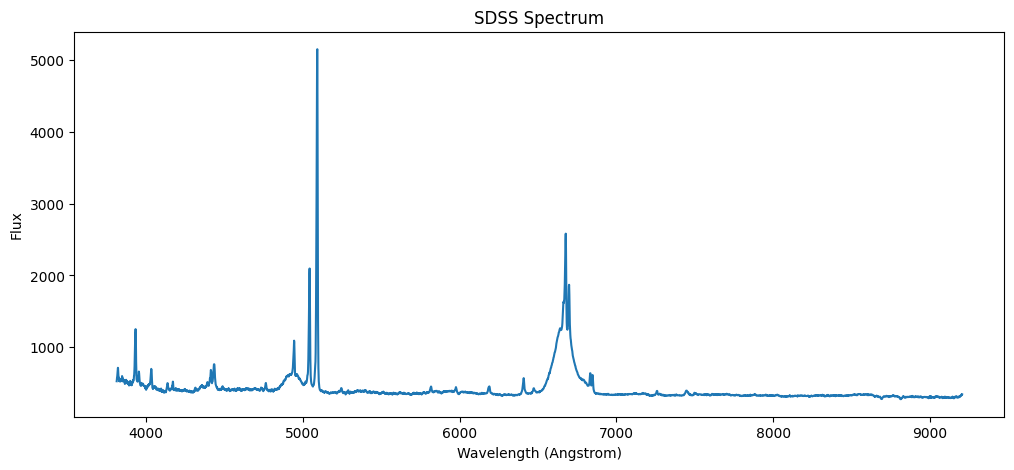

In [36]:
# Open first spectrum
hdul = spec[0]

data = hdul[1].data

flux = data['flux']
loglam = data['loglam']

# Convert wavelength
wavelength = 10**loglam

plt.figure(figsize=(12,5))
plt.plot(wavelength, flux)

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("SDSS Spectrum")

plt.show()

In [25]:
import numpy as np
import plotly.graph_objects as go

# ---- FIX ENDIANNESS ----
wavelength_native = np.array(wavelength, dtype=np.float64)
flux_native = np.array(flux, dtype=np.float64)

# ---- CREATE FIGURE ----
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=wavelength_native,
        y=flux_native,
        mode='lines',
        name='SDSS Spectrum'
    )
)

# ======================
# SPECTRAL REFERENCE LINES
# ======================

# Rest wavelengths (Angstrom)
spectral_lines = {
    "Hα": 6562.8,
    "Hβ": 4861.3,
    "[OIII]": 5006.8,
    "[OII]": 3727.0,
    "Na D": 5892.0,
    "Mg b": 5175.0
}

# Redshift guess (change manually)
z_guess = 0.0

# Add vertical lines
for name, rest_wl in spectral_lines.items():

    observed_wl = rest_wl * (1 + z_guess)

    fig.add_vline(
        x=observed_wl,
        line_dash="dash",
        annotation_text=name,
        annotation_position="top"
    )

# ---- LAYOUT ----
fig.update_layout(
    title="SDSS Spectrum - Interactive Viewer with Reference Lines",
    xaxis_title="Wavelength (Angstrom)",
    yaxis_title="Flux",
    hovermode="x"
)

fig.update_xaxes(rangeslider_visible=True)

fig.update_layout(
    xaxis=dict(showspikes=True),
    yaxis=dict(showspikes=True)
)

fig.show()

In [28]:
# ======================
# REDSHIFT CALCULATOR
# ======================

# Enter values here (Angstrom)
lambda_observed = 6683.44 # change this
lambda_rest = 6562.8  # example: H-alpha

# Redshift formula
z = (lambda_observed - lambda_rest) / lambda_rest

speed = z * 299792

#print(f"Observed wavelength = {lambda_observed} Å")
#print(f"Rest wavelength = {lambda_rest} Å")
print(f"Redshift z = {z:.5f}")
print(f"Speed = {speed} km/s")

Redshift z = 0.01838
Speed = 5510.895788382981 km/s


In [26]:
z = hdul[2].data['Z'][0]

print("Redshift (z) =", z)

Redshift (z) = 0.018181425
